# Popularity Based Recommender

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
recommendation_df = pd.read_csv(
    "../data/recommendation_dataset.csv"
)

In [3]:
recommendation_df.shape

(1337, 20)

In [4]:
recommendation_df[
    ['product_name',
     'rating',
     'rating_count',
     'popularity_score']
].head()

,product_name,rating,rating_count,popularity_score
0,Wayona Nylon Braided USB to Lightning Fast Cha...,4.2,24269.0,42.407384
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,4.0,43994.0,42.767325
2,Sounce Fast Phone Charging Cable & Data Sync U...,3.9,7928.0,35.015301
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,4.2,94363.0,48.110643
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,4.2,16905.0,40.888780


In [5]:
top_products = (
    recommendation_df
    .sort_values(
        by='popularity_score',
        ascending=False
    )
)

In [6]:
top_products[
    ['product_name',
     'rating',
     'rating_count',
     'popularity_score']
].head(10)

,product_name,rating,rating_count,popularity_score
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",4.4,426973.0,57.043705
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",4.4,426973.0,57.043705
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,4.4,426973.0,57.043705
765,SanDisk Extreme SD UHS I 64GB Card for 4K Vide...,4.5,205052.0,55.039607
545,SanDisk Cruzer Blade 32GB USB Flash Drive,4.3,253105.0,53.498724
350,boAt Bassheads 100 in Ear Wired Earphones with...,4.1,363713.0,52.496905
388,boAt Bassheads 100 in Ear Wired Earphones with...,4.1,363713.0,52.496905
543,boAt BassHeads 100 in-Ear Wired Headphones wit...,4.1,363711.0,52.496882
1017,Swiffer Instant Electric Water Heater Faucet T...,4.8,53803.0,52.286895
639,SanDisk Ultra Dual 64 GB USB 3.0 OTG Pen Drive...,4.3,189104.0,52.245248


In [7]:
def get_top_products(top_n=10):

    return (
        recommendation_df
        .sort_values(
            by='popularity_score',
            ascending=False
        )
        [
            ['product_name',
             'rating',
             'rating_count',
             'popularity_score']
        ]
        .head(top_n)
    )

In [8]:
get_top_products()

,product_name,rating,rating_count,popularity_score
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",4.4,426973.0,57.043705
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",4.4,426973.0,57.043705
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,4.4,426973.0,57.043705
765,SanDisk Extreme SD UHS I 64GB Card for 4K Vide...,4.5,205052.0,55.039607
545,SanDisk Cruzer Blade 32GB USB Flash Drive,4.3,253105.0,53.498724
350,boAt Bassheads 100 in Ear Wired Earphones with...,4.1,363713.0,52.496905
388,boAt Bassheads 100 in Ear Wired Earphones with...,4.1,363713.0,52.496905
543,boAt BassHeads 100 in-Ear Wired Headphones wit...,4.1,363711.0,52.496882
1017,Swiffer Instant Electric Water Heater Faucet T...,4.8,53803.0,52.286895
639,SanDisk Ultra Dual 64 GB USB 3.0 OTG Pen Drive...,4.3,189104.0,52.245248


In [9]:
get_top_products(5)

,product_name,rating,rating_count,popularity_score
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",4.4,426973.0,57.043705
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",4.4,426973.0,57.043705
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,4.4,426973.0,57.043705
765,SanDisk Extreme SD UHS I 64GB Card for 4K Vide...,4.5,205052.0,55.039607
545,SanDisk Cruzer Blade 32GB USB Flash Drive,4.3,253105.0,53.498724


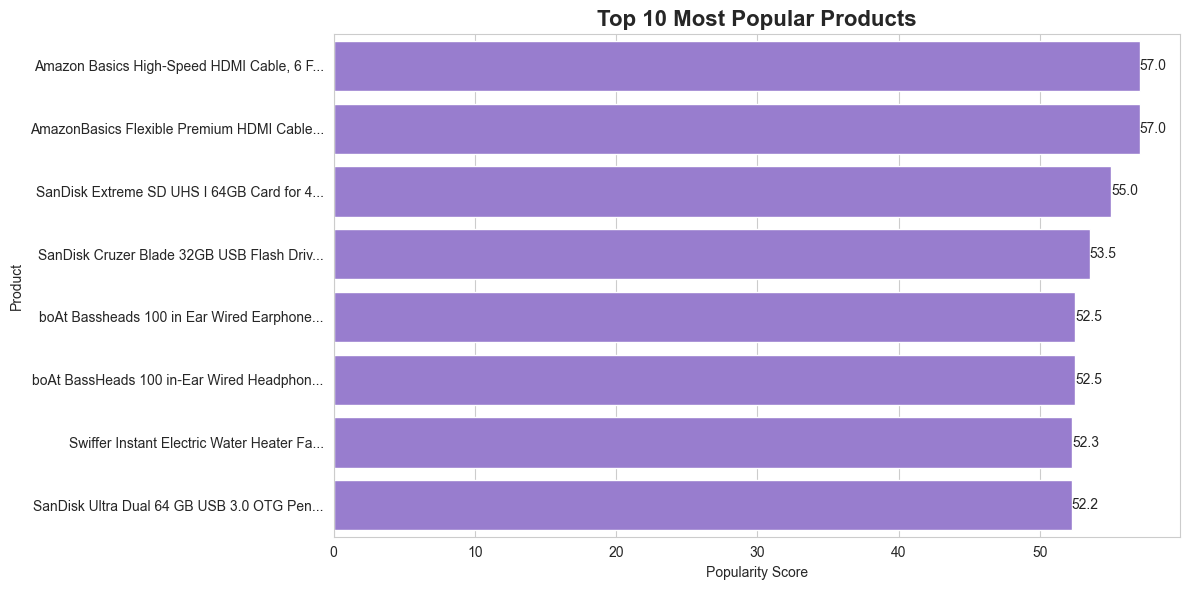

In [22]:
top10 = get_top_products(10).copy()

top10['short_name'] = (
    top10['product_name']
    .str.slice(0, 40)
    + "..."
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top10,
    x='popularity_score',
    y='short_name',
    color='mediumpurple'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.title(
    "Top 10 Most Popular Products",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Popularity Score")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [11]:
category_popularity = (
    recommendation_df
    .groupby('category')
    ['popularity_score']
    .mean()
    .sort_values(
        ascending=False
    )
)

In [12]:
category_popularity.head(10)

category
Home&Kitchen|Kitchen&Dining|KitchenTools|ManualChoppers&Chippers|Choppers     51.283882
Computers&Accessories|NetworkingDevices|NetworkAdapters|BluetoothAdapters     49.290311
Electronics|Accessories|MemoryCards|SecureDigitalCards                        49.061402
Electronics|Accessories|MemoryCards|MicroSD                                   48.755787
Computers&Accessories|ExternalDevices&DataStorage|ExternalSolidStateDrives    46.776453
Computers&Accessories|ExternalDevices&DataStorage|PenDrives                   45.830384
Computers&Accessories|Components|Memory                                       45.779957
Computers&Accessories|NetworkingDevices|Repeaters&Extenders                   45.449871
Computers&Accessories|NetworkingDevices|NetworkAdapters|PowerLANAdapters      45.079890
Electronics|PowerAccessories|SurgeProtectors                                  44.713756
Name: popularity_score, dtype: float64

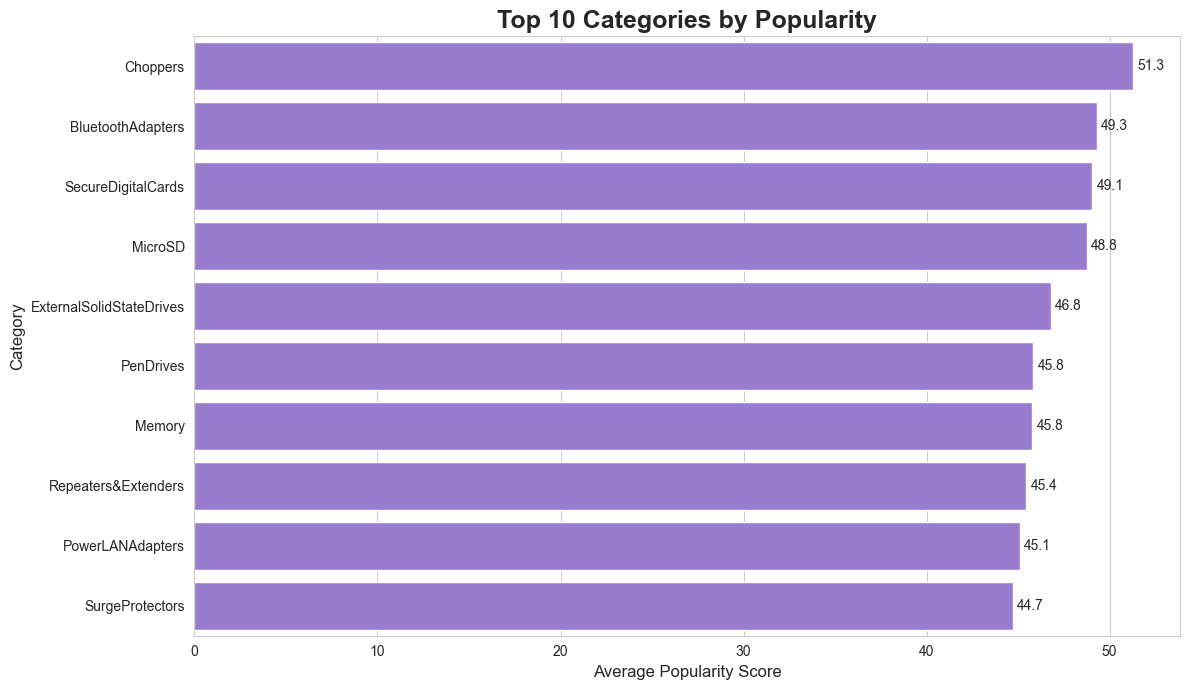

In [19]:
sns.set_style("whitegrid")

top_categories = (
    category_popularity
    .head(10)
    .reset_index()
)

# Keep only the last category level
top_categories['short_category'] = (
    top_categories['category']
    .apply(lambda x: x.split('|')[-1])
)

plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=top_categories,
    x='popularity_score',
    y='short_category',
    color='mediumpurple'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f',
        padding=3
    )

plt.title(
    "Top 10 Categories by Popularity",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "Average Popularity Score",
    fontsize=12
)

plt.ylabel(
    "Category",
    fontsize=12
)

plt.tight_layout()

plt.show()

In [14]:
def recommend_by_category(
    category_name,
    top_n=5
):

    return (
        recommendation_df[
            recommendation_df[
                'category'
            ]
            .str.contains(
                category_name,
                case=False,
                na=False
            )
        ]
        .sort_values(
            by='popularity_score',
            ascending=False
        )
        [
            ['product_name',
             'rating',
             'popularity_score']
        ]
        .head(top_n)
    )

In [15]:
recommend_by_category("Electronics")

,product_name,rating,popularity_score
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",4.4,57.043705
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",4.4,57.043705
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,4.4,57.043705
765,SanDisk Extreme SD UHS I 64GB Card for 4K Vide...,4.5,55.039607
388,boAt Bassheads 100 in Ear Wired Earphones with...,4.1,52.496905


In [16]:
recommendation_df['category'].head()

0    Computers&Accessories|Accessories&Peripherals|...
1    Computers&Accessories|Accessories&Peripherals|...
2    Computers&Accessories|Accessories&Peripherals|...
3    Computers&Accessories|Accessories&Peripherals|...
4    Computers&Accessories|Accessories&Peripherals|...
Name: category, dtype: str

In [20]:
recommend_by_category("Accessories")

,product_name,rating,popularity_score
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",4.4,57.043705
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",4.4,57.043705
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,4.4,57.043705
765,SanDisk Extreme SD UHS I 64GB Card for 4K Vide...,4.5,55.039607
545,SanDisk Cruzer Blade 32GB USB Flash Drive,4.3,53.498724


In [21]:
recommend_by_category("Memory")

,product_name,rating,popularity_score
765,SanDisk Extreme SD UHS I 64GB Card for 4K Vide...,4.5,55.039607
385,Samsung EVO Plus 128GB microSDXC UHS-I U3 130M...,4.3,50.953546
402,Samsung EVO Plus 64GB microSDXC UHS-I U1 130MB...,4.3,50.953546
699,SanDisk Ultra SDHC UHS-I Card 32GB 120MB/s R f...,4.4,49.061402
476,"SanDisk Ultra® microSDXC™ UHS-I Card, 256GB, 1...",4.4,48.911878
